In [3]:
import sys
print(sys.version)

3.9.19 (main, Mar 21 2024, 17:11:28) 
[GCC 11.2.0]


In [3]:
!pip install opencv-python

  Using cached numpy-2.0.2-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 6.8 MB/s eta 0:00:00m eta 0:00:010:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 8.3 MB/s eta 0:00:00m eta 0:00:010:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.21.6
    Uninstalling numpy-1.21.6:
      Successfully uninstalled numpy-1.21.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
astropy 5.3.4 requires numpy<2,>=1.21, but you have numpy 2.0.2 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
matplotlib 3

In [3]:
import os
import cv2
import matplotlib.pyplot as plt

In [5]:
df = "../brain_tumor/Brain Tumor Data Set"

In [7]:
#/home/admin1/brain_tumor/Brain Tumor Data Set/Brain Tumor

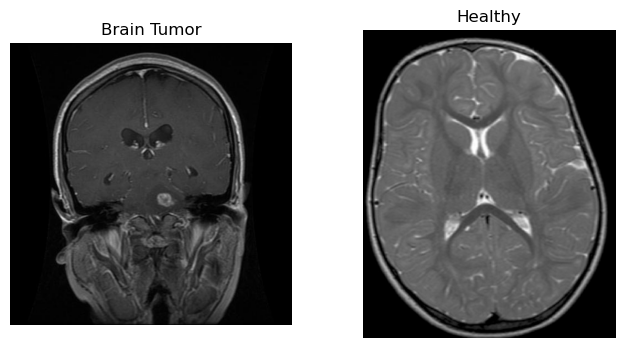

In [9]:
import os
import cv2
import matplotlib.pyplot as plt

df = "/home/admin1/brain_tumor/Brain Tumor Data Set"   # <-- FIX THIS
classes = ["Brain Tumor", "Healthy"]

plt.figure(figsize=(8,4))

for i, cls in enumerate(classes):
    folder = os.path.join(df, cls)          # class folder
    img_name = os.listdir(folder)[0]        # first image
    img_path = os.path.join(folder, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 2, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()


In [11]:
img_size = 128

In [13]:
img_resized =cv2.resize (img, (img_size, img_size))
img_normalized = img_resized/ 255.0

In [15]:
print("Original shape:", img.shape)
print("Resized shape:", img_resized.shape)
print("Pixel range after normalization:", img_normalized.min(), "to", img_normalized.max())

Original shape: (501, 411, 3)
Resized shape: (128, 128, 3)
Pixel range after normalization: 0.0 to 1.0


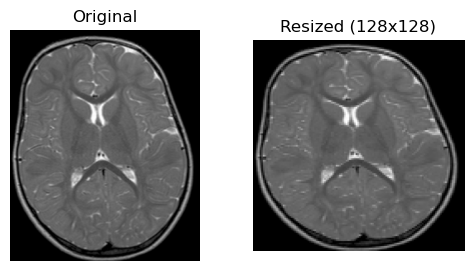

In [17]:
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_resized)
plt.title("Resized (128x128)")
plt.axis("off")

plt.show()

In [19]:
import numpy as np 
X = []
y = []

In [21]:
label_map = {
    "Brain Tumor": 1,
    "Healthy": 0
}

In [23]:
for cls in classes:
    folder = os.path.join(df, cls)
    label = label_map[cls]
    
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        
        img = cv2.imread(img_path)
        if img is None:
            continue   # skip corrupted images
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        img = img / 255.0
        
        X.append(img)
        y.append(label)


In [24]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4600, 128, 128, 3)
y shape: (4600,)


In [25]:
!pip uninstall -y numpy scipy scikit-learn

Found existing installation: numpy 1.23.5
Uninstalling numpy-1.23.5:
  Successfully uninstalled numpy-1.23.5
Found existing installation: scipy 1.9.3
Uninstalling scipy-1.9.3:
  Successfully uninstalled scipy-1.9.3
Found existing installation: scikit-learn 1.2.2
Uninstalling scikit-learn-1.2.2:
  Successfully uninstalled scikit-learn-1.2.2


In [26]:
!pip install numpy==1.23.5 scipy==1.9.3 scikit-learn==1.2.2

  Using cached numpy-1.23.5-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.3 kB)
  Using cached scipy-1.9.3-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (58 kB)
  Using cached scikit_learn-1.2.2-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
Using cached numpy-1.23.5-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.1 MB)
Using cached scipy-1.9.3-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (33.8 MB)
Using cached scikit_learn-1.2.2-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (9.6 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
numba 0.55.1 requires numpy<1.22,>=1.18, but

In [29]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verify shapes
print("Training set:", X_train.shape, y_train.shape)
print("Testing set:", X_test.shape, y_test.shape)

Training set: (3680, 128, 128, 3) (3680,)
Testing set: (920, 128, 128, 3) (920,)


In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

2026-01-12 16:28:49.852354: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-12 16:28:49.862943: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-12 16:28:49.942776: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-12 16:28:50.003281: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768215530.051167   17164 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768215530.06

In [37]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')   # binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

/home/admin1/anaconda3/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-12 16:29:05.809359: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
EPOCHS = 10     # good starting point
BATCH_SIZE = 32

In [41]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 143ms/step - accuracy: 0.6422 - loss: 0.6259 - val_accuracy: 0.8250 - val_loss: 0.3839
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 16s 138ms/step - accuracy: 0.8261 - loss: 0.3752 - val_accuracy: 0.8902 - val_loss: 0.2786
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 16s 142ms/step - accuracy: 0.8978 - loss: 0.2534 - val_accuracy: 0.9391 - val_loss: 0.1870
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 149ms/step - accuracy: 0.9408 - loss: 0.1599 - val_accuracy: 0.9609 - val_loss: 0.1602
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 16s 137ms/step - accuracy: 0.9610 - loss: 0.1017 - val_accuracy: 0.9641 - val_loss: 0.1230
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 16s 138ms/step - accuracy: 0.9845 - loss: 0.0574 - val_accuracy: 0.9663 - val_loss: 0.1344
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 16s 136ms/step - accuracy: 0.9808 - loss: 0.0540 - val_accuracy: 0.9761 - val_loss: 0.1066
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 16s 136ms/step - accuracy: 0.9944 - loss: 0

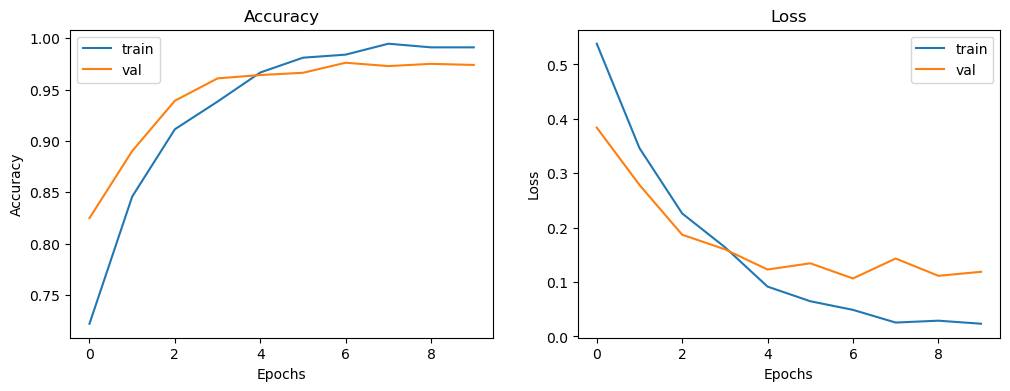

In [43]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [45]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9698 - loss: 0.1149
Test Accuracy: 97.39%
Test Loss: 0.1188


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


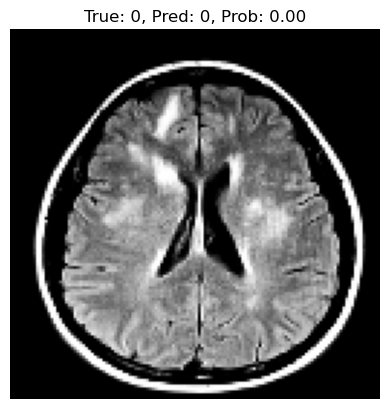

In [47]:
import random

idx = random.randint(0, X_test.shape[0]-1)
sample_img = X_test[idx]
true_label = y_test[idx]

# model expects batch dimension
pred_prob = model.predict(sample_img.reshape(1,128,128,3))[0][0]
pred_label = 1 if pred_prob > 0.5 else 0

plt.imshow(sample_img)
plt.axis('off')
plt.title(f"True: {true_label}, Pred: {pred_label}, Prob: {pred_prob:.2f}")
plt.show()